**Структура блокнота:**
Сначала у меня повторяется код с соревнования, в котором я преобрабатывал данные. Потом идем уже домашняя работа 3, где уже на обработанных данных обучается мета-модель.

In [ ]:
from scipy.stats import zscore
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt, seaborn as sns

In [2]:
from sklearn import set_config
set_config(transform_output="pandas")

In [3]:
test = pd.read_csv("test.csv")
train = pd.read_csv("train.csv")
sample_data = pd.read_csv("solution.csv")

In [4]:
train['ts_last_dt'] = pd.to_datetime(train['last_dt'])
test['ts_last_dt'] = pd.to_datetime(test['last_dt'])

# Заполняем нейтральным значением, где amt_reviews == 0
neutral_avg = train['avg_reviews'].median()  
train.loc[(train['avg_reviews'].isna()) & (train['amt_reviews'] == 0), 'avg_reviews'] = neutral_avg
neutral_avg = test['avg_reviews'].median()  
test.loc[(test['avg_reviews'].isna()) & (test['amt_reviews'] == 0), 'avg_reviews'] = neutral_avg

min_date =  min(test['ts_last_dt'].min(), train['ts_last_dt'].min())
train.loc[(train['ts_last_dt'].isna()) & (train['amt_reviews'] == 0), 'ts_last_dt'] = min_date
test.loc[(test['ts_last_dt'].isna()) & (test['amt_reviews'] == 0), 'ts_last_dt'] = min_date

max_date = max(train['ts_last_dt'].max(), test['ts_last_dt'].max())

train['days_since_last_review'] = (max_date - train['ts_last_dt']).dt.days
test['days_since_last_review'] = (max_date - test['ts_last_dt']).dt.days


cat_features = [
    'location_cluster',  # кластеризация местоположений - категориальный признак
    'type_house',  # тип жилья - категориальный признак
    'location'
]

numeric_features = [
    '_id',
    'lat',  # широта - числовой признак
    'lon',  # долгота - числовой признак
    'sum',  # общая стоимость - числовой признак
    'min_days',  # минимальное количество дней - числовой признак
    'amt_reviews',  # количество отзывов - числовой признак
    'avg_reviews',  # средний рейтинг - числовой признак
    'total_host',  # общее количество объектов у хоста - числовой признак
    'days_since_last_review'
]

_id train 0 test 0
lat train 77 test 21
lon train 916 test 320
sum train 284 test 104
min_days train 242 test 110
amt_reviews train 915 test 292
avg_reviews train 704 test 188
total_host train 493 test 187
days_since_last_review train 0 test 0


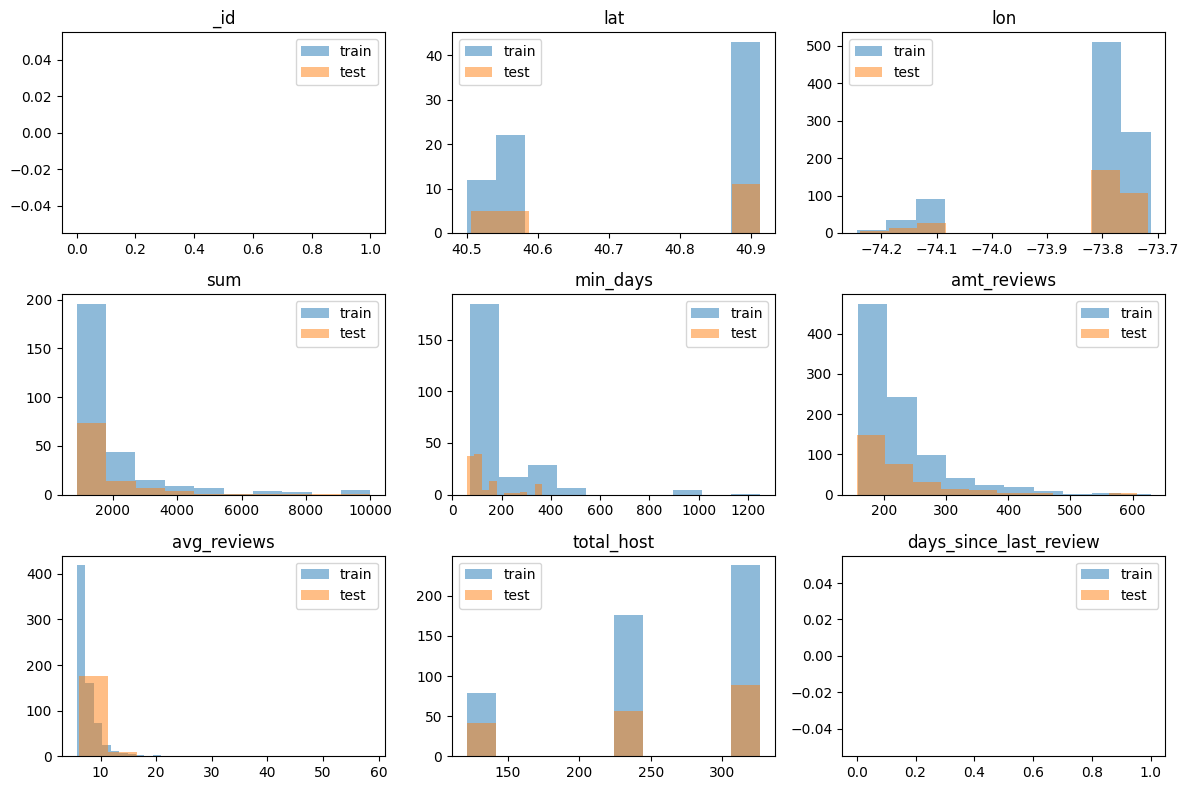

In [5]:
plt.figure(figsize=(12, 8))
for i, one_feature in enumerate(numeric_features):
  plt.subplot(3, 3, i+1)
  mask_outliesr_train = np.abs(zscore(train[one_feature].values)) >= 3
  mask_outliesr_test = np.abs(zscore(test[one_feature].values)) >= 3

  print(
      one_feature,
      'train', sum(mask_outliesr_train),
      'test', sum(mask_outliesr_test),
  )

  plt.hist(train[mask_outliesr_train][one_feature], alpha=0.5, label='train')
  plt.hist(test[mask_outliesr_test][one_feature], alpha=0.5, label='test')
  plt.legend()
  plt.title(one_feature)
plt.tight_layout()
plt.show()

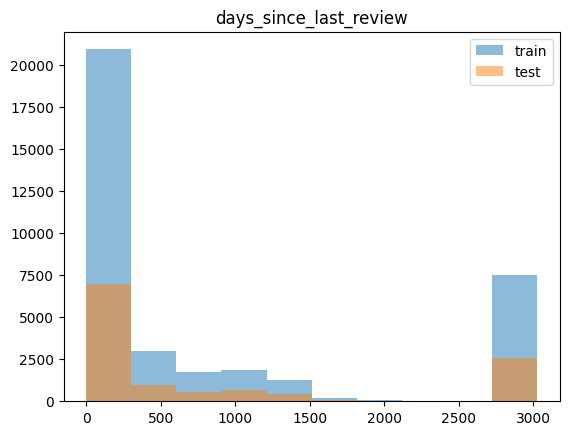

In [6]:
plt.hist(train[one_feature], alpha=0.5, label='train')
plt.hist(test[one_feature], alpha=0.5, label='test')
plt.legend()
plt.title(one_feature)
plt.show()

In [7]:
train = train[train['min_days']<400]

## Feature engeniring

In [8]:
import category_encoders as ce

target_enc = ce.CatBoostEncoder(cols=cat_features)
target_enc = target_enc.fit(train[cat_features], train['target'])

train = train.join(target_enc.transform(train[cat_features]).add_suffix('_cb'))
test = test.join(target_enc.transform(test[cat_features]).add_suffix('_cb'))

In [9]:
import numpy as np
from math import atan2, cos, radians, sin, sqrt


def haversine_distance(lat1: float, lon1: float, lat2: float, lon2: float, n_digits: int = 0) -> float:
    """
        Функция для расчёта расстояния от точки А до Б по прямой

        :param lat1: Широта точки А
        :param lon1: Долгота точки А
        :param lat2: Широта точки Б
        :param lon2: Долгота точки Б
        :param n_digits: Округляем полученный ответ до n знака после запятой
        :return: Дистанция по прямой с точностью до n_digits
    """

    lat1, lon1, lat2, lon2 = round(lat1, 6), round(lon1, 6), round(lat2, 6), round(lon2, 6)
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)

    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2

    return round(2 * 6372800 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)), n_digits)  # метры.сантиметры


def bearing_degree(lat1: float, lon1: float, lat2: float, lon2: float, n_digits: int = 0) -> float:
    """
        Функция для расчёта угла между прямой [((lat1, lon1), (lat2, lon2)), (нулевой мередиан)]

        :param lat1: Широта точки А
        :param lon1: Долгота точки А
        :param lat2: Широта точки Б
        :param lon2: Долгота точки Б
        :param n_digits: Округляем полученный ответ до n знака после запятой
        :return: Значение угла с точностью до n_digits
    """

    lat1, lon1 = np.radians(round(lat1, 6)), np.radians(round(lon1, 6))
    lat2, lon2 = np.radians(round(lat2, 6)), np.radians(round(lon2, 6))

    dlon = (lon2 - lon1)
    numerator = np.sin(dlon) * np.cos(lat2)
    denominator = np.cos(lat1) * np.sin(lat2) - (np.sin(lat1) * np.cos(lat2) * np.cos(dlon))

    theta = np.arctan2(numerator, denominator)
    theta_deg = (np.degrees(theta) + 360) % 360

    return round(theta_deg, n_digits)

In [10]:
train['bearing_degree_1'] = bearing_degree(train['lat'], train['lon'], 0, 0, ).values
test['bearing_degree_1'] = bearing_degree(test['lat'], test['lon'], 0, 0, ).values

train['hav_dist_1'] = haversine_distance(train['lat'], train['lon'], 0, 0, ).values
test['hav_dist_1'] = haversine_distance(test['lat'], test['lon'], 0, 0, ).values

In [13]:
model_features = [
  '_id',
  'lat',  # широта - числовой признак
  'lon',  # долгота - числовой признак
  'sum',  
  'min_days',
  'amt_reviews', 
  'avg_reviews', 
  'total_host',
  'days_since_last_review',
  'location_cluster_cb', 
  'type_house_cb',
  'location_cb',
  'bearing_degree_1', 
  'hav_dist_1'
]

In [42]:
test['target'] = sample_data['prediction']

# Обучение Мета-модели и Домашнее задание 3

In [86]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor

import pandas as pd
import numpy as np

# Базовые модели
base_models = [
    ("rf", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ("xgb", XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ("cat", CatBoostRegressor(n_estimators=100, random_state=42, verbose=0)),
    ("lr", LinearRegression()),
    ("lgbm", LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1))
]

X = train[model_features]
y = train['target']

n_folds = 5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# Out-of-fold и тестовые предсказания
oof_preds = np.zeros((X.shape[0], len(base_models)))
test_preds = np.zeros((test[model_features].shape[0], len(base_models)))

for i, (name, model) in enumerate(base_models):
    fold_preds = np.zeros(X.shape[0])
    test_fold_preds = np.zeros((test[model_features].shape[0], n_folds))

    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)

        fold_preds[val_idx] = model.predict(X_val)
        test_fold_preds[:, fold] = model.predict(test[model_features])

    oof_preds[:, i] = fold_preds
    test_preds[:, i] = test_fold_preds.mean(axis=1)

# Мета-модель
meta_model = LinearRegression()
meta_model.fit(oof_preds, y)
stacked_preds = meta_model.predict(oof_preds)

# MSE каждой модели и стекинга на тренировочной
mse_scores = {
    name: mean_squared_error(y, oof_preds[:, i])
    for i, (name, _) in enumerate(base_models)
}
mse_scores["stacking"] = mean_squared_error(y, stacked_preds)

# Вывод
print("На тренировочной:")
pd.DataFrame(mse_scores.items(), columns=["Модель", "MSE"])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000515 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2341
[LightGBM] [Info] Number of data points in the train set: 23317, number of used features: 14
[LightGBM] [Info] Start training from score 114.708796
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000646 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2338
[LightGBM] [Info] Number of data points in the train set: 23317, number of used features: 14
[LightGBM] [Info] Start training from score 114.637861
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000433 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2337
[LightGBM] [Info] Number of data points in the train set: 23318, number of used features: 14
[LightGBM] [Info] Start

,Модель,MSE
0,rf,10134.027699
1,xgb,10497.516626
2,cat,10255.195073
3,lr,13198.847315
4,lgbm,10189.246706
5,stacking,9843.823735


In [87]:
model_names = [name for name, _ in base_models]
test_preds_df = pd.DataFrame(test_preds, columns=model_names)
test_stacking_predict = meta_model.predict(test_preds)

test_preds_df['target'] = test_stacking_predict

In [88]:
# MSE каждой модели и стекинга на тестовой
mse_scores = {
    name: mean_squared_error(test['target'], test_preds[:, i])
    for i, (name, _) in enumerate(base_models)
}
mse_scores["stacking"] = mean_squared_error(test['target'], test_stacking_predict)

# Вывод
print("На тестовой:")
pd.DataFrame(mse_scores.items(), columns=["Модель", "MSE"])

На тестовой:


,Модель,MSE
0,rf,11447.130730
1,xgb,10155.263594
2,cat,10421.065135
3,lr,21149.952558
4,lgbm,10296.022858
5,stacking,10167.328387


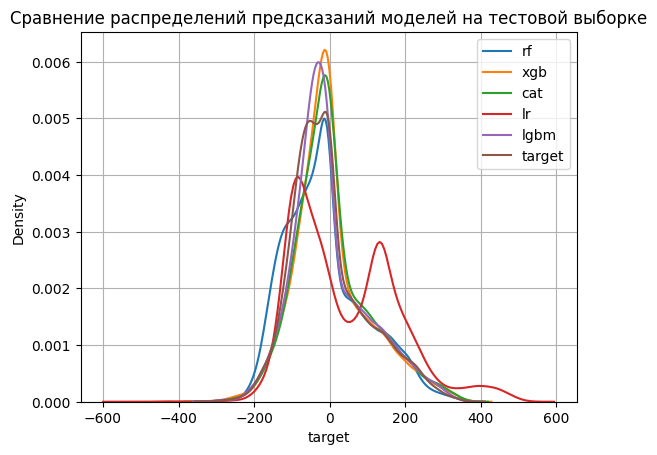

In [91]:
for one_col in test_preds_df.columns:
  sns.kdeplot(test['target'] - test_preds_df[one_col], label=one_col)

plt.title("Сравнение распределений предсказаний моделей на тестовой выборке")
plt.legend()
plt.grid()
plt.show()

In [76]:
def calculate_aleatoric_uncertainty(y_true, y_pred):
  n = len(y_true)
  residuals = y_true - y_pred
  aleatoric_uncertainty = np.sum(residuals**2) / n

  return aleatoric_uncertainty


def calculate_epistemic_uncertainty(y_pred_ensemble):
  mean_prediction = np.mean(y_pred_ensemble, axis=0)
  m = y_pred_ensemble.shape[0]  # Number of models

  squared_diffs = np.sum((y_pred_ensemble - mean_prediction)**2, axis=0)
  epistemic_uncertainty = squared_diffs / m
  return epistemic_uncertainty

In [89]:
aleatoric_uncertainty = np.mean([calculate_aleatoric_uncertainty(test['target'], i) for i in test_preds.T])
epistemic_uncertainty = np.mean(calculate_epistemic_uncertainty(test_preds))

total_uncertainty = epistemic_uncertainty + aleatoric_uncertainty

In [90]:
print(f'Средняя алеаторная неопределенность: {aleatoric_uncertainty}')
print(f'Средняя эпистемическая неопределенность: {epistemic_uncertainty}')
print(f'Общая неопределенность: {total_uncertainty}')

Средняя алеаторная неопределенность: 12693.886975157247
Средняя эпистемическая неопределенность: 7656.528410397356
Общая неопределенность: 20350.415385554603


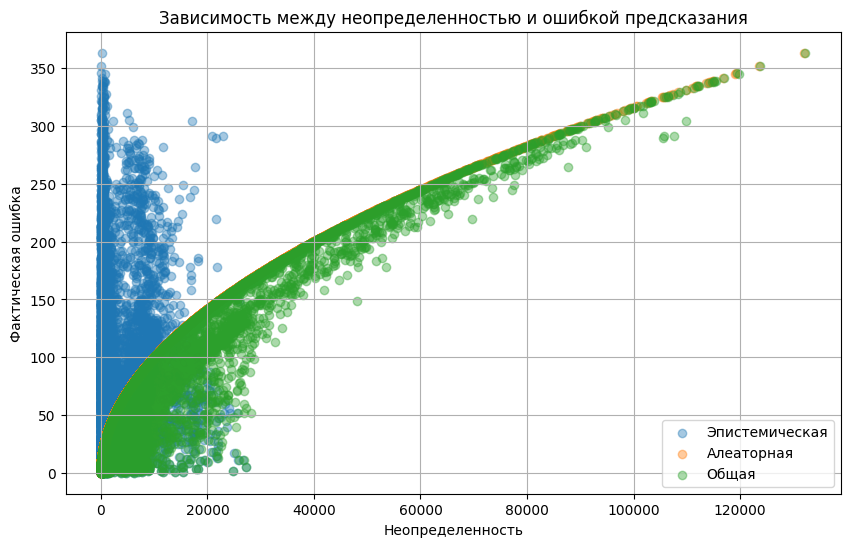

In [ ]:
epistemic_uncertainty = test_preds.var(axis=1)
aleatoric_uncertainty = (test_stacking_predict - test['target']) ** 2

total_uncertainty = epistemic_uncertainty + aleatoric_uncertainty

# 3. В
uncertainty_df = pd.DataFrame({
    "true": test['target'],
    "pred": test_stacking_predict,
    "error": np.abs(test_stacking_predict - test['target']),
    "epistemic": epistemic_uncertainty,
    "aleatoric": aleatoric_uncertainty,
    "total": total_uncertainty
})

# 5. Визуализация: ошибка vs неопределенность
plt.figure(figsize=(10, 6))
plt.scatter(uncertainty_df["epistemic"], uncertainty_df["error"], alpha=0.4, label="Эпистемическая")
plt.scatter(uncertainty_df["aleatoric"], uncertainty_df["error"], alpha=0.4, label="Алеаторная")
plt.scatter(uncertainty_df["total"], uncertainty_df["error"], alpha=0.4, label="Общая")
plt.xlabel("Неопределенность")
plt.ylabel("Фактическая ошибка")
plt.legend()
plt.title("Зависимость между неопределенностью и ошибкой предсказания")
plt.grid(True)
plt.show()

### Выводы по работе мета-модели (стекинга)

**Эффективность стекинга**:
   **На тренировочной выборке** cтекинг достиг минимального MSE (**9843.82**), превзойдя все базовые модели (например, XGBoost: 10497.52, LightGBM: 10189.25). Это подтверждает, что ансамблирование позволяет объединить сильные стороны отдельных алгоритмов. НО **На тестовой выборке** стекинг показал результат (**10167.33**) хуже, чем XGBoost (10155.26). Это указывает, что стекинг требует пересмотра подходов к его построению. Например: 
   1. Исключить слабые модели, такие как линейная регрессия.
   2. Попробовать другие мета-модели: Вместо линейной регрессии для финального объединения можно использовать более сложные алгоритмы
   3. Добавить разнообразия: Включить в ансамбль модели принципиально другого типа (kNN, SVM, etc.), чтобы увеличить полезность стекинга.
   

---

### Анализ неопределенности предсказаний

**Интерпретация**:
- Алеаторная неопределённость отражает шум в самих данных (например, внешние факторы, которые не зафиксированы признаками). Её высокая величина указывает на присутствие случайности в таргете, которую невозможно устранить.
  
- Эпистемическая неопределённость показывает неуверенность моделей. Её значение относительно велико, что говорит о неоднозначности данных и потенциале для улучшения (например, через сбор дополнительных данных или инжиниринг признаков).

**Визуальный анализ**:
На графике зависимости между неопределённостью и ошибкой видно:
1. Явная зависимость: видно, что с ростом как эпистемической, так и общей неопределённости увеличивается фактическая ошибка. Это подтверждает, что оценки неопределённости хорошо отражают надёжность модели.

2. Разный характер распределения:

   - Эпистемическая (синяя) часто принимает маленькие значения, но приводит к большим ошибкам — это указывает на локальные участки высокой неоднозначности в модели.

   - Алеаторная и общая (оранжевая и зелёная) показывают почти квадратичную зависимость, что ожидаемо, так как они строятся на квадрате ошибок.
